### Understanding Semantic Similarity Between Sentence Pairs Using GloVe Embeddings

In this notebook, we build and evaluate a sentence-pair similarity approach using the **Semantic Textual Similarity Benchmark (STS-B)** dataset from Hugging Face:

https://huggingface.co/datasets/sentence-transformers/stsb

The dataset contains pairs of sentences annotated with human similarity scores, making it suitable for evaluating how well computational methods can estimate semantic relatedness between two pieces of text.

The main objective of this notebook is to compute the similarity between sentence pairs using **GloVe word embeddings with 50 dimensions**. Each sentence is represented by converting its words into their corresponding GloVe vectors and then aggregating these word vectors into a single sentence-level representation. After generating sentence embeddings, **cosine similarity** is used to measure how closely related the two sentences are in meaning.

This notebook focuses on the following steps:

1. Loading and preparing the STS-B sentence-pair dataset.
2. Loading pre-trained 50-dimensional GloVe word embeddings.
3. Converting each sentence into a matrix of word embedding vectors.
4. Generating sentence-level embeddings by averaging word vectors.
5. Computing cosine similarity between sentence embeddings.
6. Comparing the computed similarity scores with the original human-annotated similarity scores.

The purpose of this experiment is to understand how traditional word embeddings such as GloVe can be used for document and sentence similarity tasks without relying on transformer-based models.

### Imports

In the following code cell, we will import all the necessary packages that will be used throughout this notebook.  
These include libraries for data handling, visualization, and model development.


In [1]:
import random
import torch
import warnings
import seaborn as sns
import os
import json
import re
import time
import html

from collections import Counter, defaultdict
from sklearn.metrics.pairwise import cosine_similarity
from helperfns.tables import tabulate_data
from pigmenta import PALETTES
from helperfns.utils import hms_string
from sklearn.utils import resample
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')

print("torch: ", torch.__version__)
print("numpy: ", np.__version__)
print("pandas: ", pd.__version__)

torch:  2.9.0+cu126
numpy:  1.26.4
pandas:  2.3.3


### Setting Seeds

In the following code cell, we will set a fixed seed value for all random operations to ensure **reproducibility** of the results.  
This helps guarantee that the model produces consistent outputs every time the notebook is run.


In [2]:
SEED = 23
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deteministic = True

### Dataset

In this notebook, we use the **Semantic Textual Similarity Benchmark (STS-B)** dataset from Hugging Face:

https://huggingface.co/datasets/sentence-transformers/stsb

The dataset was downloaded directly from Hugging Face as CSV files and loaded into **Pandas DataFrames**. It contains sentence pairs together with human-annotated similarity scores, making it suitable for evaluating how well computational methods can estimate semantic similarity between two text inputs.

The dataset is divided into three subsets:

- `training.csv` for training and experimentation
- `validation.csv` for model validation and parameter tuning
- `testing.csv` for final evaluation

```python
train_df = pd.read_csv("training.csv")
valid_df = pd.read_csv("validation.csv")
test_df = pd.read_csv("testing.csv")
```

The main objective of this experiment is to compute the semantic similarity between two sentences or documents using GloVe word embeddings with 50 dimensions. Each sentence is converted into a matrix of word vectors, where each word is represented by its corresponding 50-dimensional GloVe embedding. These word vectors are then aggregated into a single sentence-level or document-level representation.

After obtaining the vector representation for each text, cosine similarity is used to measure how similar the two texts are in meaning. The computed similarity scores are then compared with the original human-annotated similarity scores provided in the STS-B dataset.

This dataset is suitable for this notebook because it provides paired text examples and similarity labels, which align directly with the goal of evaluating sentence and document similarity using traditional word embedding techniques.

In [3]:
train_df = pd.read_csv('training.csv')
valid_df = pd.read_csv('validation.csv')
test_df = pd.read_csv('testing.csv')

### Merging the Dataset Splits

After loading the training, validation, and testing CSV files, the three subsets are merged into a single DataFrame. This allows the full dataset to be analyzed together when computing sentence or document similarity using GloVe embeddings.

The `pd.concat()` function is used to combine the three DataFrames row-wise, while `ignore_index=True` resets the index of the merged dataset.


In [4]:
dataframe = pd.concat([train_df, valid_df, test_df], ignore_index=True)
dataframe.head(2)

,sentence1,sentence2,score
0,A plane is taking off.,An air plane is taking off.,1.00
1,A man is playing a large flute.,A man is playing a flute.,0.76


In the following code cell we are going to remove the `Na` values and null values as a way of cleaning the dataset.

In [5]:
def drop_na(dataframe):
    if sum(dataframe.isna().any()):
      dataframe.dropna(inplace=True)
      dataframe.reset_index(drop=True, inplace=True)
    dataframe.isna().any()
drop_na(dataframe)
dataframe.head(2)

,sentence1,sentence2,score
0,A plane is taking off.,An air plane is taking off.,1.00
1,A man is playing a large flute.,A man is playing a flute.,0.76


Next we are going to check the size of the dataset after this modification.

In [6]:
print(f"The dataset size is: {len(dataframe):,}")

The dataset size is: 8,628


### Distribution of Similarity Scores

In the following code cell, we examine the distribution of similarity scores across the entire dataset using a histogram.

Since the dataset contains pairs of documents or sentences with similarity scores ranging from 0 to 1, the histogram helps us understand how the similarity values are spread across the dataset. This allows us to observe whether most document pairs have low, medium, or high semantic similarity.

This step is important because it provides an overview of the dataset before applying GloVe embeddings and cosine similarity. By analyzing the score distribution, we can better understand the nature of the document-pair relationships represented in the dataset.

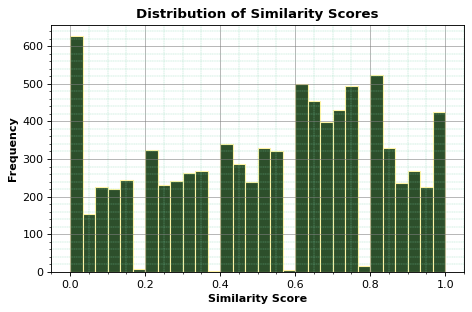

In [7]:
plt.figure(figsize=(6, 4), dpi=80)
plt.hist(dataframe["score"], bins=30, edgecolor=PALETTES.nature[4], color=PALETTES.nature[0])
plt.title("Distribution of Similarity Scores", weight="bold")
plt.xlabel("Similarity Score", weight="bold")
plt.ylabel("Frequency", weight="bold")
plt.minorticks_on()
plt.grid(which='major', color='gray', linestyle='-', linewidth=0.5)
plt.grid(which='minor', color='#7ED4AD', linestyle='--', linewidth=0.3)
plt.tight_layout()
plt.show()

### Boxplot of Similarity Scores

In the following code cell, we visualize the distribution of similarity scores using a boxplot.

The boxplot provides a compact summary of the score distribution by showing the median, lower quartile, upper quartile, and possible outliers. Since the similarity scores range from 0 to 1, this visualization helps us understand how concentrated or spread out the document similarity values are across the dataset.

This analysis is useful for identifying whether most document pairs have generally low, moderate, or high similarity, and whether there are unusual similarity scores that may require further inspection.

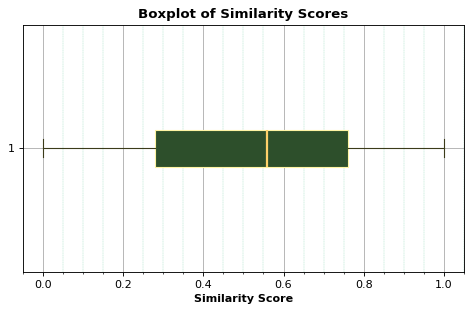

In [8]:
plt.figure(figsize=(6, 4), dpi=80)
plt.boxplot(
    dataframe["score"],
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor=PALETTES.nature[0], color=PALETTES.nature[4]),
    medianprops=dict(color=PALETTES.nature[5], linewidth=2),
    whiskerprops=dict(color=PALETTES.nature[8]),
    capprops=dict(color=PALETTES.nature[8]),
    flierprops=dict(markerfacecolor=PALETTES.nature[6], markeredgecolor=PALETTES.nature[7])
)
plt.title("Boxplot of Similarity Scores",  weight="bold")
plt.xlabel("Similarity Score", weight="bold")
plt.minorticks_on()
plt.grid(which='major', color='gray', linestyle='-', linewidth=0.5)
plt.grid(which='minor', color='#7ED4AD', linestyle='--', linewidth=0.3)
plt.tight_layout()
plt.show()

### Density Plot of Similarity Scores

In the following code cell, we visualize the distribution of similarity scores using a density plot.

A density plot provides a smooth representation of the score distribution across the dataset. Since the similarity scores range from 0 to 1, this visualization helps us observe where most document-pair similarity values are concentrated.

Unlike a histogram, which groups values into bins, the density plot shows the overall shape of the distribution more smoothly. This makes it easier to identify whether the dataset contains more low-similarity, medium-similarity, or high-similarity document pairs.

This step is useful for understanding the general pattern of similarity scores before computing cosine similarity using GloVe-based document embeddings.

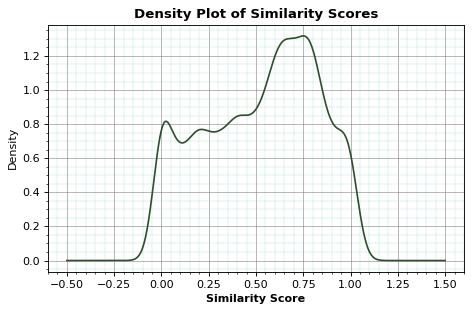

In [9]:
plt.figure(figsize=(6, 4), dpi=80)
dataframe["score"].plot(kind="density", color=PALETTES.nature[0])
plt.title("Density Plot of Similarity Scores", weight="bold")
plt.xlabel("Similarity Score", weight="bold")
plt.minorticks_on()
plt.grid(which='major', color='gray', linestyle='-', linewidth=0.5)
plt.grid(which='minor', color='#7ED4AD', linestyle='--', linewidth=0.3)
plt.tight_layout()
plt.show()

### Categorizing Similarity Scores

In the following step, the similarity scores are grouped into three categories: **Low Similarity**, **Medium Similarity**, and **High Similarity**.

Since the similarity scores range from 0 to 1, the categories are defined using threshold values that represent different levels of semantic relatedness between document pairs. Scores closer to 0 indicate that the two documents are less similar, while scores closer to 1 indicate that the documents are highly similar.

The score categories are defined as follows:

- **Low Similarity:** scores from 0.0 to 0.3
- **Medium Similarity:** scores greater than or equal to 0.3 and less than 0.7
- **High Similarity:** scores greater than or equal to 0.7 and up to 1.0

This categorization makes it easier to interpret the dataset by showing how many document pairs fall into each similarity level. It also helps provide a clearer understanding of whether the dataset contains more weakly related, moderately related, or highly related document pairs.

The categorized scores can then be visualized using a bar chart to compare the number of document pairs in each similarity group.

In [10]:
def score_category(score):
    if score < .3:
        return "Low"
    elif score < .7:
        return "Medium"
    else:
        return "High"
dataframe["score_category"] = dataframe["score"].apply(score_category)
dataframe["score_category"].value_counts()

score_category
Medium    3406
High      2946
Low       2276
Name: count, dtype: int64

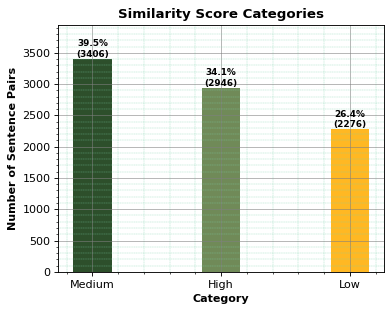

In [11]:
counts = dataframe["score_category"].value_counts()
labels, values = counts.index, counts.values
def fmt_bar(x, total):
    return '{:.1f}%\n({:.0f})'.format(x/total *100, x)

plt.figure(figsize=(5, 4), dpi=80 )
plt.ylim(0, max(values) * 1.16)
bars = plt.bar(labels, values, width=.3, color=PALETTES.nature)

for index, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        fmt_bar(values[index], sum(values)),
        ha='center',
        va='bottom',
        fontsize=8,
        weight='bold'
    )
plt.title("Similarity Score Categories", weight='bold')
plt.xlabel("Category", weight='bold')
plt.ylabel("Number of Sentence Pairs", weight='bold')
plt.minorticks_on()
plt.grid(which='major', color='gray', linestyle='-', linewidth=0.5)
plt.grid(which='minor', color='#7ED4AD', linestyle='--', linewidth=0.3)
plt.tight_layout()
plt.show()

### Data Cleaning

Before computing semantic similarity between document pairs, the dataset must be cleaned and preprocessed. This step helps remove noise, normalize the text, and ensure that both documents in each pair are represented consistently before applying GloVe word embeddings.

The dataset contains paired text samples together with their corresponding similarity scores. Since the goal is to compare the meaning of two documents or sentences, both text columns must undergo the same cleaning process.

The cleaning process includes:

- Converting text to lowercase
- Removing unnecessary punctuation and special characters
- Removing extra spaces
- Removing unwanted symbols that may not contribute to semantic meaning
- Ensuring that missing or empty text values are handled properly

This preprocessing step is important because GloVe embeddings depend on matching words in the text with words in the embedding vocabulary. Cleaning the text improves the chances of finding valid word vectors and reduces inconsistencies caused by capitalization, punctuation, or noisy characters.

The following function is used to perform the cleaning process:

In [12]:
MENTION_HASHTAG_RE = re.compile(r"(@|#)([A-Za-z0-9_]+)")
EMAIL_RE = re.compile(r"([A-Za-z0-9]+[._-])*[A-Za-z0-9]+@[A-Za-z0-9-]+(\.[A-Za-z]{2,})+")
URL_RE = re.compile(r"https?://\S+|www\.\S+")
HTML_TAG_RE = re.compile(r"<.*?>")
DIGIT_RE = re.compile(r"\d+")
PUNCT_RE = re.compile(r"[^\w\s']")
SPACE_RE = re.compile(r"\s+")

def clean_sentence(sent: str, lower: bool = True) -> str:
    sent = html.unescape(sent)
    if lower:
        sent = sent.lower()
    sent = HTML_TAG_RE.sub(" ", sent)
    sent = MENTION_HASHTAG_RE.sub(" ", sent)
    sent = EMAIL_RE.sub(" ", sent)
    sent = URL_RE.sub(" ", sent)
    sent = DIGIT_RE.sub(" ", sent)
    sent = PUNCT_RE.sub(" ", sent)
    sent = SPACE_RE.sub(" ", sent).strip()
    return sent

print("Unclean Example: ", dataframe.iloc[10].sentence1)
print("\n\nClean Example: ", clean_sentence(dataframe.iloc[10].sentence1))

Unclean Example:  The man hit the other man with a stick.


Clean Example:  the man hit the other man with a stick


In the following code cell we are going to apply the `clean_sentence` function to our dataset so that it will be cleaned.

In [13]:
dataframe['sentence1'] = dataframe.sentence1.apply(clean_sentence)
dataframe['sentence2'] = dataframe.sentence2.apply(clean_sentence)

dataframe.head(2)

,sentence1,sentence2,score,score_category
0,a plane is taking off,an air plane is taking off,1.00,High
1,a man is playing a large flute,a man is playing a flute,0.76,High


In [14]:
sentences_1 = dataframe.sentence1.values
sentences_2 = dataframe.sentence2.values
scores = dataframe.score.values

### Building a Custom Vocabulary

Next, we create a **Counter object** to store the frequency of each word in the dataset.

The word counts are generated from the cleaned text data and will be used to build a custom vocabulary for the similarity analysis. This step is important because it allows us to identify the words that appear in the dataset and determine which of them have corresponding vectors in the pre-trained GloVe embedding file.

By counting the words in the dataset, we can:

- Track how often each word appears
- Build a vocabulary based on the dataset
- Remove rare or noisy words if necessary
- Match dataset words with available GloVe embeddings
- Prepare the text for sentence or document vector representation

The vocabulary created from these word counts will later be used to convert documents into numerical representations using 50-dimensional GloVe word embeddings.

In [15]:
counter = Counter()

for line in (sentences_1 + sentences_2):
    counter.update(line.lower().split())


### Data

In addition to the sentence-pair similarity scores, this notebook uses **pre-trained GloVe word embeddings** to convert words into dense numerical vectors. These embeddings allow words with related meanings to have similar vector representations, making them useful for measuring semantic similarity between documents or sentences.

The main goal is to represent each document or sentence as a vector and then compute the similarity between two text inputs using cosine similarity.

### How GloVe Will Be Used

In this notebook, GloVe embeddings will be used to support document similarity computation through the following steps:

1. Load pre-trained GloVe word embeddings with 50 dimensions.
2. Convert each word in a sentence or document into its corresponding GloVe vector.
3. Represent each sentence or document as a matrix of word embedding vectors.
4. Aggregate the word vectors into a single document-level or sentence-level vector, commonly by averaging the vectors.
5. Compute cosine similarity between the two resulting vectors.
6. Compare the computed similarity score with the original similarity score provided in the dataset.

Using GloVe embeddings allows the notebook to capture semantic relationships between words based on pre-trained word representations, rather than relying only on exact word matching.

### Pretrained GloVe Vectors

In the following code cell, we load the pre-trained **GloVe.6B.50d** word embeddings.

These embeddings were trained on a large corpus containing approximately 6 billion tokens. Each word is represented as a **50-dimensional vector**, where the vector values capture semantic and contextual relationships between words.

The 50-dimensional version of GloVe is used in this notebook because it is lightweight and suitable for similarity experiments. It provides a good balance between computational efficiency and semantic representation quality, especially when working in a notebook environment.

The loaded GloVe vectors will be used to convert words from the STS-B dataset into numerical representations before computing document or sentence similarity.

In [16]:
embedding_path = "C://Users//crisp//Documents//glove.6B//glove.6B.50d.txt"
EMBEDDING_DIM = 50
glove_vectors = dict()
with open(embedding_path, encoding="utf8") as glove:
  for line in glove:
    records = line.split();
    word = records[0]
    vectors = np.asarray(records[1: ], dtype=np.float32)
    glove_vectors[word] = vectors

### Why GloVe Word Embeddings Were Used

In this notebook, we use **GloVe word embeddings** to represent words as numerical vectors before computing document or sentence similarity. Since computers cannot directly understand raw text, each word must first be converted into a numerical form. A simple approach is one-hot encoding, where each word is represented by a long sparse vector containing mostly zeros and a single value of one. However, one-hot encoding does not capture meaning because all words are treated as equally different from one another.

Word embeddings solve this problem by representing words as dense vectors of real numbers. Instead of using very large sparse vectors, embeddings map words into a lower-dimensional vector space where words with similar meanings or usage patterns are placed closer together. For example, words such as `shop` and `store` often appear in similar contexts and are therefore expected to have similar vector representations.

GloVe, which stands for **Global Vectors for Word Representation**, is a pre-trained word embedding method that learns word relationships from global word co-occurrence statistics in a large text corpus. The main idea is that words appearing in similar contexts tend to carry related meanings. Therefore, GloVe vectors can capture semantic relationships between words based on how frequently they occur together with other words.

In this notebook, we use **GloVe.6B.50d**, where:

- `6B` means the embeddings were trained on a corpus containing approximately 6 billion tokens.
- `50d` means each word is represented by a 50-dimensional vector.

The 50-dimensional version was selected because it is lightweight and suitable for notebook-based experiments. It provides a good balance between semantic representation quality and computational efficiency.

### How Word Embeddings Work

Word embeddings work by placing words into a continuous vector space. In this vector space, words that occur in similar contexts are located closer to one another. This means that semantic similarity can be estimated by measuring the distance or angle between word vectors.

For example, the sentences:

```text
I purchased some items at the shop.
I purchased some items at the store.
```


use the words `shop` and `store` in a similar context. Because these words often appear in similar surroundings, their GloVe vectors are expected to be close to each other in the embedding space.

This property makes word embeddings useful for similarity tasks. Instead of comparing documents only by exact word matching, embeddings allow us to compare texts based on their underlying meaning.

### How GloVe Is Used in This Notebook

The STS-B dataset contains pairs of sentences or documents with human-annotated similarity scores. To compute similarity using GloVe, each text is first tokenized into words. Each word is then matched with its corresponding 50-dimensional GloVe vector.

For each sentence or document, the word vectors are combined into a single text-level representation. In this notebook, this is done by averaging the word vectors. This produces one fixed-size vector for each text, regardless of how many words it contains.

The process can be summarized as follows:

1. Clean and tokenize each sentence or document.
2. Look up each word in the GloVe vocabulary.
3. Retrieve the 50-dimensional vector for each known word.
4. Average the word vectors to create one sentence-level or document-level vector.
5. Compute cosine similarity between the two resulting vectors.
6. Compare the computed cosine similarity score with the original human-annotated score in the dataset.

### Why GloVe Is Suitable for This Task

GloVe is suitable for this similarity task because it provides pre-trained semantic knowledge learned from a large corpus. This allows the notebook to compute meaningful text similarity without training word embeddings from scratch.

Using GloVe also makes the approach computationally efficient. Since the vectors are already trained, the notebook only needs to load them and use them for similarity computation. This is useful when working in limited environments such as Jupyter notebooks, where large transformer-based models may be too slow or may cause memory issues.

Although GloVe does not capture sentence meaning as deeply as modern transformer models, it provides a strong traditional baseline for document and sentence similarity. It also helps demonstrate how word-level semantic representations can be combined to produce sentence-level or document-level similarity scores.



### Inspecting Word Embedding Vectors

In the following code cell, we create a function that retrieves the GloVe word embedding vector for a given word.

This function allows us to take a closer look at how individual words are represented in the embedding space. Each word in the GloVe vocabulary is stored as a dense numerical vector, where the values capture semantic information learned from word co-occurrence patterns in a large corpus.

By retrieving and inspecting word vectors, we can better understand how GloVe represents words numerically before using these vectors to compute sentence-level or document-level similarity.


In [17]:
def get_vector(embedding, word):
    assert word in glove_vectors, f'{word} not in the vocab' 
    return torch.from_numpy(glove_vectors[word])
get_vector(glove_vectors, 'the').shape

torch.Size([50])

### Similar Contexts

Next, we explore how GloVe captures contextual similarity between words.

Word embeddings are based on the idea that words appearing in similar contexts tend to have similar meanings. Therefore, if two words are used in similar surrounding environments, their vectors are expected to be close to each other in the embedding space.

To find words that are similar to a given input word, we first retrieve the GloVe vector for that word. We then compare this vector with the vectors of other words in the vocabulary by computing a distance or similarity measure. The words are then sorted based on how close they are to the input word vector.

Words with smaller distances or higher similarity scores are considered more semantically related to the input word.

The function below returns the closest 10 words to a given input word vector:

In [18]:
def closest_words(embeddings, vector, n = 10):
    distances = [(word, torch.dist(vector, get_vector(embeddings, word)).item())
                 for word in embeddings.keys()]
    return sorted(distances, key = lambda w: w[1])[:n]

### Testing Similar Word Retrieval with `football`

We can now test the similarity function using the word `football`.

When `football` is used as the input word, the closest word returned is `football` itself with a distance of `0.0`. This is expected because a word is identical to its own vector representation. The remaining words provide more useful insight into how GloVe captures semantic and contextual relationships.

The closest related words include `soccer`, `league`, `basketball`, `club`, `hockey`, `rugby`, `team`, `baseball`, and `coaching`. These words are strongly connected to the sports domain. For example, `soccer` is closely related to `football`, especially because the term `football` can refer to different sports depending on the country or context. Words such as `league`, `club`, and `team` are also commonly used in discussions about football and organized sports.

Interestingly, other sports such as `basketball`, `hockey`, `rugby`, and `baseball` also appear among the closest words. This suggests that GloVe has learned that these words often occur in similar contexts, such as discussions about sports competitions, teams, players, leagues, and coaching.

This example shows that GloVe embeddings capture more than direct word meanings. They also capture broader contextual associations based on how words are used in large text corpora. As a result, words that belong to the same topic or domain tend to be positioned close to one another in the embedding space.

In [19]:
word_vector = get_vector(glove_vectors, 'football')
pd.DataFrame(
    closest_words(glove_vectors, word_vector),
    columns=["word", "distance"]
)

,word,distance
0,football,0.000000
1,soccer,2.701771
2,league,2.881880
3,basketball,2.919534
4,club,3.117890
5,hockey,3.126600
6,rugby,3.268548
7,team,3.393623
8,baseball,3.718578
9,coaching,3.761908


### Testing Similar Word Retrieval with `drink`

We can now test the similar-word retrieval function using the word `drink`.

When `drink` is used as the input word, the closest word returned is usually `drink` itself. This is expected because a word has the smallest distance from its own vector representation. The remaining returned words are more useful because they show which words GloVe considers contextually or semantically related to `drink`.

Words that appear close to `drink` are likely to be related to beverages, actions involving drinking, or common contexts where the word is used. For example, related words may include terms such as `drinks`, `drinking`, `beer`, `coffee`, `water`, `wine`, or other beverage-related words, depending on the GloVe vocabulary and distance calculation.

This example helps demonstrate that GloVe captures contextual relationships between words. Since words related to beverages and consumption often appear in similar contexts, their vectors tend to be positioned close to each other in the embedding space.

In [20]:
word_vector = get_vector(glove_vectors, 'drink')
pd.DataFrame(
    closest_words(glove_vectors, word_vector),
    columns=["word", "distance"]
)

,word,distance
0,drink,0.000000
1,drinks,2.047495
2,beer,2.885294
3,coffee,3.123950
4,bottled,3.128167
5,drinking,3.171988
6,soda,3.248752
7,milk,3.284311
8,drank,3.463073
9,sodas,3.474387


### Word Analogies

Another useful property of word embeddings is that they can be treated like standard mathematical vectors. Since each word is represented as a dense numerical vector, we can perform vector operations such as addition and subtraction to explore relationships between words.

This makes it possible to test word analogies. A common example is:

```text
king - man + woman ≈ queen
```
The idea behind word analogies is that the difference between two word vectors can represent a meaningful relationship. For example, the vector difference between `king` and `man` can capture part of the relationship associated with gender. When this relationship is added to the vector for `woman`, the resulting vector is expected to be close to words such as `queen`.

In this notebook, we use this property to explore whether GloVe embeddings capture meaningful relationships between words. After performing the vector operation, we search for the words closest to the resulting vector. The returned words help us understand how semantic patterns are represented in the embedding space.

The following code cell demonstrates a word analogy using GloVe word vectors:

In [21]:
def print_tuples(tuples):
    for w, d in tuples:
        print(f'({d:02.04f}) {w}')

In [22]:
def analogy(embeddings, word1, word2, word3, n=5):
    #get vectors for each word
    word1_vector = get_vector(embeddings, word1)
    word2_vector = get_vector(embeddings, word2)
    word3_vector = get_vector(embeddings, word3)
    #calculate analogy vector
    analogy_vector = word2_vector - word1_vector + word3_vector
    #find closest words to analogy vector
    candidate_words = closest_words(embeddings, analogy_vector, n+3)
    #filter out words already in analogy
    candidate_words = [(word, dist) for (word, dist) in candidate_words 
                       if word not in [word1, word2, word3]][:n]
    
    print(f'{word1} is to {word2} as {word3} is to...')
    return candidate_words

In [23]:
candidate_words = analogy(glove_vectors, 'man', 'king', 'woman')
pd.DataFrame(
    candidate_words,
    columns=["word", "distance"]
)

man is to king as woman is to...


,word,distance
0,queen,2.839121
1,prince,3.661004
2,elizabeth,3.715252
3,daughter,3.831788
4,widow,3.849378


In [24]:
candidate_words = analogy(glove_vectors, 'man', 'actor', 'woman')
pd.DataFrame(
    candidate_words,
    columns=["word", "distance"]
)

man is to actor as woman is to...


,word,distance
0,actress,2.052674
1,starred,3.606484
2,comedian,3.878124
3,starring,3.940674
4,entertainer,3.991979


In [25]:
candidate_words = analogy(glove_vectors, 'paris', 'france', 'harare')
pd.DataFrame(
    candidate_words,
    columns=["word", "distance"]
)

paris is to france as harare is to...


,word,distance
0,zimbabwe,3.238162
1,namibia,3.465448
2,kenya,3.556411
3,botswana,3.663091
4,uganda,3.735794


### Computing Sentence Embeddings for Similarity Scoring

Word embeddings can be used for several natural language processing tasks, such as finding similar words, solving word analogies, and identifying possible spelling corrections. In this section, we shift our focus from word-level analysis to sentence-level similarity.

To compute similarity between two sentences, each sentence must first be converted into a fixed-size numerical vector. Since GloVe provides embeddings at the word level, we represent a sentence by retrieving the embedding vector for each word and then averaging all word vectors.

Let a sentence be represented as:

$$
S = \{w_1, w_2, w_3, ..., w_n\}
$$

where $n$ represents the total number of words in the sentence.

Each word $w_i$ is mapped to a 50-dimensional GloVe vector:

$$
v_i \in R^{50}
$$

If the word exists in the GloVe vocabulary, its pretrained vector is used:

$$
v_i = GloVe(w_i)
$$

If the word is not found in the GloVe vocabulary, it is treated as an unknown word. In this case, a random vector is used as a fallback representation:

$$
v_i \sim N(0, 1)
$$

This means that each value in the unknown word vector is sampled from a normal distribution with mean 0 and standard deviation 1.

After retrieving all word vectors, the sentence vector is computed by averaging the word embeddings:

$$
s = \frac{1}{n} \sum_{i=1}^{n} v_i
$$

where:

- $s$ is the final sentence embedding.
- $n$ is the number of words in the sentence.
- $v_i$ is the 50-dimensional embedding vector of the $i$-th word.

This averaging step converts a sentence of any length into a single fixed-size vector:

$$
s \in R^{50}
$$

The resulting sentence embedding can then be used to compute cosine similarity between two sentences. This allows us to compare the semantic closeness of sentence pairs using their GloVe-based vector representations.

In [26]:
def get_sentence_matrix(line):
    matrix = []
    vector = list(np.random.normal(0, 1, 50))
    for word in line.split():
        try:
            vector = list(glove_vectors[word])
        except Exception:
            pass
        matrix.append(vector) 
    return np.array(matrix, dtype=np.float32).mean(axis=0)

matrix_1 = get_sentence_matrix("this is a boy")
matrix_2 = get_sentence_matrix("this is a boy")
matrix_2

array([ 0.26071   ,  0.435545  , -0.38544   ,  0.02562   ,  0.8330749 ,
        0.5294575 , -0.44922903, -0.2319275 ,  0.102934  ,  0.1809175 ,
        0.1018075 ,  0.054365  , -0.17615   ,  0.038745  ,  0.52925503,
        0.05450001, -0.04013498,  0.37033498, -0.40235752, -0.015345  ,
       -0.42107773,  0.24320251, -0.09821124,  0.29800326,  0.2642    ,
       -2.006225  , -0.52881503,  0.3973025 ,  0.289839  , -0.16293375,
        3.4994001 , -0.54079   , -0.31099   , -0.1187975 ,  0.20905049,
        0.04363   ,  0.224195  , -0.0695575 ,  0.17836249, -0.4917725 ,
       -0.14362076,  0.244459  , -0.5034225 , -0.02943009,  0.09738377,
       -0.099045  ,  0.111305  , -0.337483  ,  0.29524   ,  0.2314875 ],
      dtype=float32)

In the following code cell we are going to count the words that were not found in the `glove_vectors` which are the `OOV`.

In [50]:
def get_oov_count(lines, glove_vectors):
    oov_words = {}
    total_tokens = 0
    oov_tokens = 0

    for line in lines:
        if not isinstance(line, str):
            continue

        for word in line.split():
            total_tokens += 1

            if word not in glove_vectors:
                oov_tokens += 1
                oov_words[word] = oov_words.get(word, 0) + 1

    oov_percentage = (oov_tokens / total_tokens) * 100 if total_tokens > 0 else 0

    return {
        "total_tokens": total_tokens,
        "oov_tokens": oov_tokens,
        "unique_oov_words": len(oov_words),
        "oov_percentage": oov_percentage,
        "oov_words": oov_words
    }

print("\n================== Sentence 1")
results = get_oov_count(dataframe.sentence1, glove_vectors)
print(f"Total tokens: {results['total_tokens']}")
print(f"OOV tokens: {results['oov_tokens']}")
print(f"Unique OOV words: {results['unique_oov_words']}")
print(f"OOV percentage: {results['oov_percentage']:.2f}%")

print("\n================== Sentence 2")

results = get_oov_count(dataframe.sentence2, glove_vectors)
print(f"Total tokens: {results['total_tokens']}")
print(f"OOV tokens: {results['oov_tokens']}")
print(f"Unique OOV words: {results['unique_oov_words']}")
print(f"OOV percentage: {results['oov_percentage']:.2f}%")

print("\n================== Sentence 1 + Sentence 2")
all_sentences = list(dataframe.sentence1) + list(dataframe.sentence2)
results = get_oov_count(all_sentences, glove_vectors)
print(f"Total tokens: {results['total_tokens']}")
print(f"OOV tokens: {results['oov_tokens']}")
print(f"Unique OOV words: {results['unique_oov_words']}")
print(f"OOV percentage: {results['oov_percentage']:.2f}%")


================== Sentence 1
Total tokens: 86787
OOV tokens: 1396
Unique OOV words: 773
OOV percentage: 1.61%

================== Sentence 2
Total tokens: 86631
OOV tokens: 1417
Unique OOV words: 779
OOV percentage: 1.64%

================== Sentence 1 + Sentence 2
Total tokens: 173418
OOV tokens: 2813
Unique OOV words: 1215
OOV percentage: 1.62%


### Computing Cosine Similarity

After converting each sentence into a fixed-size GloVe-based sentence vector, the next step is to compute how similar the two sentence vectors are. In this notebook, we use the `cosine_similarity` function from `sklearn.metrics.pairwise`.

Cosine similarity measures the cosine of the angle between two vectors. It is useful for text similarity because it focuses on the direction of the vectors rather than their magnitude. This means that two sentences can be considered similar if their vectors point in a similar direction in the embedding space.

Let the first sentence vector be represented as:

$$
\mathbf{s}_1 = [s_{11}, s_{12}, s_{13}, ..., s_{1d}]
$$

and the second sentence vector be represented as:

$$
\mathbf{s}_2 = [s_{21}, s_{22}, s_{23}, ..., s_{2d}]
$$

where $d$ is the embedding dimension. In this notebook, since we are using GloVe.6B.50d, the dimension is:

$$
d = 50
$$

The cosine similarity between the two sentence vectors is computed as:

$$
\text{cosine similarity}(\mathbf{s}_1, \mathbf{s}_2)
=
\frac{\mathbf{s}_1 \cdot \mathbf{s}_2}
{\|\mathbf{s}_1\| \|\mathbf{s}_2\|}
$$

The dot product between the two vectors is:

$$
\mathbf{s}_1 \cdot \mathbf{s}_2
=
\sum_{i=1}^{d} s_{1i}s_{2i}
$$

The magnitude, or Euclidean norm, of each vector is computed as:

$$
\|\mathbf{s}_1\|
=
\sqrt{\sum_{i=1}^{d} s_{1i}^{2}}
$$

and

$$
\|\mathbf{s}_2\|
=
\sqrt{\sum_{i=1}^{d} s_{2i}^{2}}
$$

Therefore, the full cosine similarity formula can be written as:

$$
\text{cosine similarity}(\mathbf{s}_1, \mathbf{s}_2)
=
\frac{\sum_{i=1}^{d} s_{1i}s_{2i}}
{\sqrt{\sum_{i=1}^{d} s_{1i}^{2}} \sqrt{\sum_{i=1}^{d} s_{2i}^{2}}}
$$

The output score usually ranges from -1 to 1:

- A score close to $1$ means the two sentence vectors are highly similar.
- A score close to $0$ means the two sentence vectors are weakly related or unrelated.
- A score close to $-1$ means the two vectors point in opposite directions.

In this notebook, a higher cosine similarity score indicates that the two sentences or documents are more semantically similar according to their GloVe-based vector representations.

In [27]:
cosine_similarity(
    [matrix_1],
    [matrix_2]
)[0][0]

1.0

### Computing and Storing Cosine Similarity Scores

In the following code cell, we compute the cosine similarity score for each pair of sentences in the dataset.

Instead of printing the results one by one, the computed scores are stored in a new Pandas DataFrame. This makes the results easier to inspect, filter, visualize, and compare with the original human-annotated similarity scores from the dataset.

For each sentence pair, the process is as follows:

1. Convert the first sentence into a GloVe-based sentence vector.
2. Convert the second sentence into a GloVe-based sentence vector.
3. Compute the cosine similarity between the two sentence vectors.
4. Store the first sentence, second sentence, original score, and computed cosine similarity score in a DataFrame.

This allows us to compare the original similarity score with the GloVe-based cosine similarity score in a structured format.

In [28]:
sentences_1[:5], sentences_2[:5], scores[:5]

(array(['a plane is taking off', 'a man is playing a large flute',
        'a man is spreading shreded cheese on a pizza',
        'three men are playing chess', 'a man is playing the cello'],
       dtype=object),
 array(['an air plane is taking off', 'a man is playing a flute',
        'a man is spreading shredded cheese on an uncooked pizza',
        'two men are playing chess', 'a man seated is playing the cello'],
       dtype=object),
 array([1.  , 0.76, 0.76, 0.52, 0.85]))

In [29]:
results = []
for sent1, sent2, og_score in zip(sentences_1, sentences_2, scores):
    matrix_1 = get_sentence_matrix(sent1)
    matrix_2 = get_sentence_matrix(sent2)

    sim_score = cosine_similarity(
        [matrix_1],
        [matrix_2]
    )[0][0]

    results.append({
        "sentence_1": sent1,
        "sentence_2": sent2,
        "original_score": og_score,
        "cosine_score": sim_score
    })

similarity_df = pd.DataFrame(results)
similarity_df.head()

,sentence_1,sentence_2,original_score,cosine_score
0,a plane is taking off,an air plane is taking off,1.00,0.982979
1,a man is playing a large flute,a man is playing a flute,0.76,0.991267
2,a man is spreading shreded cheese on a pizza,a man is spreading shredded cheese on an uncoo...,0.76,0.967470
3,three men are playing chess,two men are playing chess,0.52,0.999284
4,a man is playing the cello,a man seated is playing the cello,0.85,0.988563


### Sorting Sentence Pairs by Cosine Similarity Score

After computing the GloVe-based cosine similarity scores, the resulting DataFrame can be sorted using the `cosine_score` column.

Sorting the DataFrame from highest to lowest allows us to inspect the sentence pairs that the GloVe-based approach considers most semantically similar. These pairs are expected to have cosine similarity scores closer to 1.

Sorting from lowest to highest allows us to examine sentence pairs with weaker semantic similarity. These pairs usually have cosine similarity scores closer to 0 or lower.

This step is useful for comparing the computed cosine similarity scores with the original human-annotated similarity scores. It also helps identify sentence pairs where the GloVe-based similarity approach performs well and cases where it may not align closely with the original similarity score.

In [30]:
og_dataframe = pd.concat([train_df, valid_df, test_df], ignore_index=True)
og_dataframe.head(2)

,sentence1,sentence2,score
0,A plane is taking off.,An air plane is taking off.,1.00
1,A man is playing a large flute.,A man is playing a flute.,0.76


In [31]:
similarity_df_sorted = similarity_df.sort_values(
    by="cosine_score",
    ascending=False
)

similarity_df_sorted.head()

,sentence_1,sentence_2,original_score,cosine_score
3946,traffic accidents leave dead in china,traffic accidents leave dead in china,0.48,1.0
2448,could this have been an enema,could this have been an enema,0.92,1.0
3868,bodies found at russian jet crash in indonesia,bodies found at russian jet crash in indonesia,0.76,1.0
2664,the gloves are off said unifi official rob o'n...,unifi official rob o'neill said the gloves are...,1.00,1.0
4625,suicide bombs hit egypt military in sinai kill,suicide bombs hit egypt military in sinai kill,0.56,1.0


In [32]:
og_dataframe.iloc[similarity_df_sorted.head().index]

,sentence1,sentence2,score
3946,2 Traffic Accidents Leave 47 Dead in China,3 traffic accidents leave 56 dead in China,0.48
2448,Could this have been an enema?,"@ossobuco, Could this have been an enema?",0.92
3868,Bodies Found at Russian Jet Crash in Indonesia,12 bodies found at Russian jet crash in Indonesia,0.76
2664,"""The gloves are off,"" said UNIFI official Rob ...","Unifi official Rob O'Neill said: ""The gloves a...",1.00
4625,"Suicide Bombs Hit Egypt Military in Sinai, Kill 6","Suicide bombs hit Egypt military in Sinai, kill 4",0.56


In [44]:
print(og_dataframe.iloc[2664].sentence1)

"The gloves are off," said UNIFI official Rob O'Neill.


In [34]:
similarity_df_sorted.tail()

,sentence_1,sentence_2,original_score,cosine_score
8400,samsung overtakes nokia in phones,charges over dog attack on police,0.00,0.409333
4049,australian among four on plane missing in indo...,iranian painter mansoureh hosseini dies,0.00,0.408663
3985,bradley triumphs at firestone as furyk fades,bahrain court upholds sentences against uprisi...,0.00,0.397890
4138,'whitey' bulger's girlfriend gets years,mobster whitey bulger's girlfriend gets years,0.72,0.293314
4689,china's new stealth frigate commissioned,belarus latvia to set up border commission,0.04,0.218892


In [35]:
og_dataframe.iloc[similarity_df_sorted.tail().index]

,sentence1,sentence2,score
8400,Samsung overtakes Nokia in phones,Charges over dog attack on police,0.00
4049,Australian among four on plane missing in Indo...,Iranian painter Mansoureh Hosseini dies,0.00
3985,Bradley triumphs at Firestone as Furyk fades,Bahrain court upholds sentences against uprisi...,0.00
4138,'Whitey' Bulger's girlfriend gets 8 years,"Mobster ""Whitey"" Bulger's girlfriend gets 8 years",0.72
4689,China's new stealth frigate commissioned,"Belarus, Latvia to set up border commission",0.04


### Evaluation Metrics for Comparing Original and Cosine Similarity Scores

After computing the GloVe-based cosine similarity scores, we evaluate how closely they match the original human-annotated similarity scores from the dataset.

Since both `original_score` and `cosine_score` are continuous numerical values, this evaluation can be treated as a regression-style comparison. The goal is to measure both the relationship between the two scores and the size of the error between them.

Let the original similarity score be represented as:

$$
y_i
$$

and the computed GloVe cosine similarity score be represented as:

$$
\hat{y}_i
$$

where:

- $y_i$ is the original human-annotated similarity score for the $i$-th sentence pair.
- $\hat{y}_i$ is the computed cosine similarity score for the $i$-th sentence pair.
- $n$ is the total number of sentence pairs.

### Pearson Correlation

Pearson correlation measures the strength of the linear relationship between the original scores and the computed cosine similarity scores.

It is calculated as:

$$
r =
\frac{
\sum_{i=1}^{n}(y_i - \bar{y})(\hat{y}_i - \bar{\hat{y}})
}{
\sqrt{\sum_{i=1}^{n}(y_i - \bar{y})^2}
\sqrt{\sum_{i=1}^{n}(\hat{y}_i - \bar{\hat{y}})^2}
}
$$

where:

- $\bar{y}$ is the mean of the original scores.
- $\bar{\hat{y}}$ is the mean of the computed cosine scores.

A Pearson correlation close to `1` means that the computed cosine scores increase as the original scores increase. A value close to `0` indicates a weak linear relationship.

### Spearman Correlation

Spearman correlation measures how well the ranking of the computed cosine scores matches the ranking of the original scores.

Unlike Pearson correlation, Spearman correlation does not focus on exact score values. Instead, it compares the rank order of the scores.

It is calculated as:

$$
\rho =
1 -
\frac{6\sum_{i=1}^{n} d_i^2}{n(n^2 - 1)}
$$

where:

- $d_i$ is the difference between the rank of $y_i$ and the rank of $\hat{y}_i$.
- $n$ is the number of sentence pairs.

Spearman correlation is useful when we want to know whether sentence pairs that have high original similarity scores are also ranked highly by the GloVe cosine similarity method.

### Mean Absolute Error

Mean Absolute Error, or MAE, measures the average absolute difference between the original scores and the computed cosine scores.

It is calculated as:

$$
MAE =
\frac{1}{n}
\sum_{i=1}^{n}
|y_i - \hat{y}_i|
$$

A lower MAE means that the computed cosine scores are closer to the original similarity scores.

### Mean Squared Error

Mean Squared Error, or MSE, measures the average squared difference between the original scores and the computed cosine scores.

It is calculated as:

$$
MSE =
\frac{1}{n}
\sum_{i=1}^{n}
(y_i - \hat{y}_i)^2
$$

MSE penalizes larger errors more strongly because the errors are squared.

### Root Mean Squared Error

Root Mean Squared Error, or RMSE, is the square root of the Mean Squared Error.

It is calculated as:

$$
RMSE =
\sqrt{
\frac{1}{n}
\sum_{i=1}^{n}
(y_i - \hat{y}_i)^2
}
$$

RMSE is useful because it is expressed on the same scale as the original scores and cosine scores.

### R-squared Score

R-squared measures how much of the variation in the original similarity scores is explained by the computed cosine similarity scores.

It is calculated as:

$$
R^2 =
1 -
\frac{
\sum_{i=1}^{n}(y_i - \hat{y}_i)^2
}{
\sum_{i=1}^{n}(y_i - \bar{y})^2
}
$$

where:

- $y_i$ is the original score.
- $\hat{y}_i$ is the computed cosine score.
- $\bar{y}$ is the mean of the original scores.

An $R^2$ value closer to `1` indicates better agreement between the computed cosine scores and the original scores. A value close to `0` means that the cosine scores explain little of the variation in the original scores.


In [47]:
y_true = similarity_df["original_score"]
y_pred = similarity_df["cosine_score"]
pearson_corr, pearson_p_value = pearsonr(y_true, y_pred)
spearman_corr, spearman_p_value = spearmanr(y_true, y_pred)

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)

r2 = r2_score(y_true, y_pred)
metrics_df = pd.DataFrame({
    "Metric": [
        "Pearson Correlation",
        "Pearson P-value",
        "Spearman Correlation",
        "Spearman P-value",
        "Mean Absolute Error",
        "Mean Squared Error",
        "Root Mean Squared Error",
        "R-squared Score"
    ],
    "Value": [
        pearson_corr,
        pearson_p_value,
        spearman_corr,
        spearman_p_value,
        mae,
        mse,
        rmse,
        r2
    ]
})

metrics_df

,Metric,Value
0,Pearson Correlation,0.398655
1,Pearson P-value,0.000000
2,Spearman Correlation,0.467648
3,Spearman P-value,0.000000
4,Mean Absolute Error,0.418878
5,Mean Squared Error,0.248536
6,Root Mean Squared Error,0.498534
7,R-squared Score,-1.815118
